In [1]:
import os
import sys

from dotenv import load_dotenv

load_dotenv("../../.env")

# src 디렉토리를 Python path에 추가
sys.path.insert(0, os.path.abspath("../src"))

%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

## Context Offloading: Filesystem

<img src="./assets/agent_header_files.png" width="800" style="display:block; margin-left:0;">

복잡한 작업 수행 중 에이전트 컨텍스트 창은 급격히 커질 수 있습니다. 평균적인 Manus 작업은 약 50회의 도구 호출을 사용하며, 이로 인해 상당한 양의 컨텍스트가 축적됩니다. 이러한 증가를 관리하는 강력한 기법은 파일 시스템 작업을 통한 **컨텍스트 오프로딩**입니다. 에이전트는 모든 도구 호출 관측값과 중간 결과를 컨텍스트 윈도우에 직접 저장하는 대신, 정보를 전략적으로 파일에 저장하고 [필요할 때 불러올](https://blog.langchain.com/context-engineering-for-agents/) 수 있습니다. 이를 통해 핵심 정보에 대한 접근성을 유지하면서도 작업에 집중할 수 있습니다.


이 접근 방식은 [Manus](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) 및 [Hugging Face Open Deep Research](https://huggingface.co/blog/open-deep-research)와 같은 실제 운영 시스템에서 성공적으로 구현되었습니다. Anthropic의 [다중 에이전트 연구 시스템](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Subagent%20output%20to%20a%20filesystem%20to%20minimize%20the%20%E2%80%98game%20of%20telephone.% E2%80%99)는 또 다른 설득력 있는 예시를 제공합니다. 여기서 하위 에이전트는 자신의 작업을 외부 시스템에 저장하고 가벼운 참조 정보를 코디네이터에게 다시 전달합니다. 이는 여러 에이전트를 거치며 정보가 퇴색되는 “전화 게임” 효과를 방지하는 동시에, 새로운 하위 에이전트가 깨끗한 컨텍스트로 생성되도록 하고 필요할 때 메모리에서 연구 계획과 같은 저장된 컨텍스트를 검색할 수 있게 합니다.


에이전트가 토큰이 많은 컨텍스트를 샌드박스 환경의 파일에 기록함으로써, 메모리를 효율적으로 관리하면서도 필요할 때 상세한 정보를 검색할 수 있는 능력을 유지할 수 있습니다. 이 패턴은 일반적인 코디네이터를 통해 필터링하는 것보다 특화된 프롬프트가 더 나은 결과를 산출하는 코드, 보고서, 데이터 시각화와 같은 구조화된 출력물이나, 지속적인 관리 없이도 중간 결과를 보존해야 하는 장기 연구 작업에 특히 유용합니다.

### File Tools

본 구현은 LangGraph state 내에서 기존 파일 시스템을 모의(mock)하는 가상 파일 시스템 방식을 사용합니다. 핵심은 키가 모의 파일 경로를 나타내고 값이 파일 내용을 포함하는 간단한 딕셔너리를 활용하는 것입니다. 이 방식은 단일 에이전트 대화 내에서 컨텍스트를 유지하는 데 이상적인 단기적, 스레드 단위의 지속성을 제공하지만, 서로 다른 대화 스레드 간에 지속되어야 하는 정보에는 적합하지 않습니다. 파일 작업은 LangGraph의 `Command` 타입을 활용하여 에이전트 상태를 업데이트하므로, 도구가 가상 파일 시스템을 수정하고 에이전트 실행 전반에 걸쳐 적절한 상태 관리를 유지할 수 있습니다.

가상 파일 시스템에서 작동하는 세 가지 파일 도구—`ls`, `read_file`, `write_file`—를 구현하게 됩니다.

**Usage:** 
- LLM이 컨텍스트에 보존하고자 하는 정보가 있을 경우, `write_file`을 사용하여 이를 파일에 기록합니다. 이후 동일한 에이전트나 하위 에이전트가 `read_file`을 통해 해당 정보를 불러올 수 있습니다.
- 도구 호출을 통해 데이터를 파일에 기록하고, 도구 호출 반환 메시지에 파일 이름을 LLM에 제공할 수 있습니다. LLM은 나중에 해당 내용의 일부 또는 전부를 읽기로 결정하거나, 데이터를 처리하기 위해 다른 도구를 적용할 수 있습니다.
- `ls`를 사용하여 사용 가능한 파일 목록을 확인하십시오.

read/write 도구는 줄바꿈으로 구분된 일반 텍스트(`str.splitlines()`로 파싱된)를 입력으로 받습니다.


아래 프롬프트의 설명을 통해 각 도구의 작동 방식을 자세히 확인할 수 있습니다:

<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>Note:</b>  
The <code>create_react_agent</code> was moved from the LangGraph library to the LangChain library and renamed to <code>create_agent</code> in the 1.0 code release post-filming. There are slight changes to the imports and code to accommodate this. The video may display the previous configuration.
</div>

In [3]:
from utils import show_prompt

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION,
    READ_FILE_DESCRIPTION,
    WRITE_FILE_DESCRIPTION,
)

show_prompt(LS_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  에이전트 state에 저장된 가상 파일 시스템의 모든 파일을 나열합니다.                                             │
│                                                                                                                 │
│  에이전트 memory에 현재 존재하는 파일을 표시합니다. 다른 파일 작업을 수행하기 전에 상황을 파악하고 파일 구조를  │
│  확인하는 데 이 기능을 사용하십시오.                                                                            │
│                                                                                                                 │
│  매개변수가 필요하지 않습니다. ls()를 호출하기만 하면 사용 가능한 모든 파일을 확인할 수 있습니다.               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [4]:
show_prompt(READ_FILE_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  가상 파일 시스템에 있는 파일의 내용을 선택적 페이지 단위로 읽습니다.                                           │
│                                                                                                                 │
│  이 도구는 줄 번호와 함께 파일 내용을 반환하며(`cat -n`과 유사), 컨텍스트 오버플로를 방지하기 위해 대용량       │
│  파일을 여러 조각으로 나누어 읽을 수 있습니다.                                                                  │
│                                                                                                                 │
│  매개변수:                                                                                                      │
│  - file_path (필수): 읽을 파일의 경로                                                                           │
│  - offset (선택 사항, 기본값=0): 읽기를 시작할 줄 번호                                                          │
│  - limit (선택 사항, 기본값=2000): 읽을 최대 줄 수                                                              │
│                                                                                                                 │
│  편집을 시작하기 전에 기존 내용을 파악하는 것은 필수적입니다. 파일을 편집하기 전에 항상 내용을 읽어보십시오.    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [5]:
show_prompt(WRITE_FILE_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  가상 파일 시스템에서 새 파일을 생성하거나 기존 파일을 완전히 덮어씁니다.                                       │
│                                                                                                                 │
│  이 도구는 새 파일을 생성하거나 파일 전체 내용을 덮어씁니다. 초기 파일 생성 또는 전체 재작성 시 사용하십시오.   │
│  파일은 에이전트 state에 영구적으로 저장됩니다.                                                                 │
│                                                                                                                 │
│  매개변수:                                                                                                      │
│  - file_path (required): 파일을 생성하거나 덮어쓸 경로                                                          │
│  - content (required): 파일에 기록할 전체 내용                                                                  │
│                                                                                                                 │
│  중요: 이 작업은 파일 전체 내용을 덮어씁니다.                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

이제 아래에서 이 함수들을 구현해 봅시다. 주목할 만한 두 가지 사항이 있습니다.   
첫 번째는 `@tool(description=PROMPT)`의 사용입니다.   
도구 데코레이터에 `description=“xyz”`가 포함되면, “xyz”가 LLM으로 전송되고 docstring은 표시되지 않는다는 점에 유의하십시오.   
긴 설명은 별도의 프롬프트 파일에 담아두는 것이 더 편리한 경우가 많습니다.   
이렇게 하면 도구의 작동 방식과 이 애플리케이션에서 도구를 어떻게 사용해야 하는지 모두 설명할 수 있는 공간을 확보할 수 있습니다.   
두 번째로 주목할 점은 오류 메시지입니다. 이 메시지들은 인간 사용자가 아닌 LLM을 대상으로 합니다.  
에이전트 기반 시스템에서 LLM은 오류 메시지에 포함된 정보를 활용하여 작업을 재시도할 수 있습니다. 

In [6]:
%%writefile ../src/deep_agents_from_scratch/file_tools.py
"""Virtual file system tools for agent state management.

This module provides tools for managing a virtual filesystem stored in agent state,
enabling context offloading and information persistence across agent interactions.
"""

from typing import Annotated

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION,
    READ_FILE_DESCRIPTION,
    WRITE_FILE_DESCRIPTION,
)
from deep_agents_from_scratch.state import DeepAgentState


@tool(description=LS_DESCRIPTION)
def ls(state: Annotated[DeepAgentState, InjectedState]) -> list[str]:
    """List all files in the virtual filesystem."""
    return list(state.get("files", {}).keys())


@tool(description=READ_FILE_DESCRIPTION, parse_docstring=True)
def read_file(
    file_path: str,
    state: Annotated[DeepAgentState, InjectedState],
    offset: int = 0,
    limit: int = 2000,
) -> str:
    """선택 사항인 오프셋 및 제한을 사용하여 가상 파일 시스템에서 파일 내용을 읽습니다.

    Args:
        file_path: 읽을 파일의 경로
        state: 가상 파일 시스템을 포함하는 에이전트 상태(툴 노드에 주입됨)
        offset: 읽기를 시작할 줄 번호(기본값: 0)
        limit: 읽을 최대 줄 수(기본값: 2000)

    Returns:
        줄 번호가 포함된 형식화된 파일 내용, 또는 파일을 찾을 수 없는 경우 오류 메시지
    """
    files = state.get("files", {})
    if file_path not in files:
        return f"Error: File '{file_path}' not found"

    content = files[file_path]
    if not content:
        return "System reminder: File exists but has empty contents"

    lines = content.splitlines()
    start_idx = offset
    end_idx = min(start_idx + limit, len(lines))

    if start_idx >= len(lines):
        return f"Error: Line offset {offset} exceeds file length ({len(lines)} lines)"

    result_lines = []
    for i in range(start_idx, end_idx):
        line_content = lines[i][:2000]  # Truncate long lines
        result_lines.append(f"{i + 1:6d}\t{line_content}")

    return "\n".join(result_lines)


@tool(description=WRITE_FILE_DESCRIPTION, parse_docstring=True)
def write_file(
    file_path: str,
    content: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """가상 파일 시스템의 파일에 내용을 기록합니다.

    Args:
        file_path: 파일을 생성하거나 업데이트할 경로
        content: 파일에 기록할 내용
        state: 가상 파일 시스템을 포함하는 에이전트 상태(툴 노드에 주입됨)
        tool_call_id: 메시지 응답을 위한 툴 호출 식별자(툴 노드에 주입됨)

    Returns:
        새로운 파일 내용으로 에이전트 상태를 업데이트하는 명령
    """
    files = state.get("files", {})
    files[file_path] = content
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(f"Updated file {file_path}", tool_call_id=tool_call_id)
            ],
        }
    )

Overwriting ../src/deep_agents_from_scratch/file_tools.py


# Revisiting state and reducer 
이전 노트북에서는 파일 상태와 리듀서를 정의했지만, 이에 대해 자세히 설명하지는 않았습니다. 여기서 그 내용을 살펴보겠습니다.
`DeepAgentState`에서 `files`는 키와 값을 가진 딕셔너리로 정의됩니다. 앞서 언급했듯이, 키는 파일 이름이고 값은 파일의 내용입니다. `write_files` 내의 `Command`가 실행될 때 `file_reducer`를 사용하여 `files`가 상태에 추가됩니다. 이 리듀서에서 `left`는 상태에 이미 존재하는 파일들을, `right`는 새로운 값들을 나타냅니다. 마지막 문장인 `{**left, **right}`은 새로운 값들이 기존 값들을 덮어쓰도록 허용합니다. 파이썬은 `left`를 먼저 풀고, 그 다음 `right`를 풉니다. `right`에 있는 중복 키들은 `left`의 기존 값들을 덮어씁니다.

```python
def file_reducer(left, right):
    """Merge two file dictionaries, with right side taking precedence.

    Used as a reducer function for the files field in agent state,
    allowing incremental updates to the virtual file system.

    Args:
        left: Left side dictionary (existing files)
        right: Right side dictionary (new/updated files)

    Returns:
        Merged dictionary with right values overriding left values
    """
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}


class DeepAgentState(AgentState):
    """Extended agent state that includes task tracking and virtual file system.

    Inherits from LangGraph's AgentState and adds:
    - todos: List of Todo items for task planning and progress tracking
    - files: Virtual file system stored as dict mapping filenames to content
    """

    todos: NotRequired[list[Todo]]
    files: Annotated[NotRequired[dict[str, str]], file_reducer]
```

가상 파일 시스템과 이를 다루는 도구들이 준비되어 있습니다. 이를 시험해 보기 위해 간단한 탐색 에이전트를 만들어 봅시다.
이 에이전트는 사용자의 요청을 저장해 두었다가, 사용자의 질문에 답하기 전에 이를 다시 읽어옵니다! 

이 간단한 접근 방식은 [장시간 실행되는 에이전트 트래잭터리에서 매우 유용합니다](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Long%2Dhorizon%20conversation,across%20extended%20interactions.)! 이 간단한 예시에서는 모든 정보를 컨텍스트에 쉽게 유지할 수 있지만, 장기 실행 에이전트의 경우 컨텍스트 내용을 압축하거나 제거할 수 있습니다. 압축 전에 정보를 저장해 두었다가 필요할 때 불러오는 것이 현명한 컨텍스트 설계입니다.

In [7]:
# File usage instructions
FILE_USAGE_INSTRUCTIONS = """당신은 컨텍스트를 유지하고 저장하는 데 도움이 되는 가상 파일 시스템에 액세스할 수 있습니다.                                  
                                                                                                                
## 워크플로우 프로세스                                                                                            
1. **확인**: 작업을 시작하기 전에 ls()를 사용하여 기존 파일을 확인합니다.                                             
2. **저장**: write_file()을 사용하여 사용자의 요청을 저장하여 나중에 사용할 수 있도록 합니다.                     
3. **읽기**: 수집한 자료가 충분하다고 판단되면, 저장된 파일을 읽어와 이를 활용하여 사용자의 질문에 직접 답변합니다."""

# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """IMPORTANT: web_search 도구를 한 번 호출한 다음, 도구가 제공하는 결과를 활용하여 사용자의 질문에 답변하면 됩니다."""

# Full prompt
INSTRUCTIONS = (
    FILE_USAGE_INSTRUCTIONS + "\n\n" + "=" * 80 + "\n\n" + SIMPLE_RESEARCH_INSTRUCTIONS
)
show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  당신은 컨텍스트를 유지하고 저장하는 데 도움이 되는 가상 파일 시스템에 액세스할 수 있습니다.                    │
│                                                                                                                 │
│  ## 워크플로우 프로세스                                                                                         │
│  1. **확인**: 작업을 시작하기 전에 ls()를 사용하여 기존 파일을 확인합니다.                                      │
│  2. **저장**: write_file()을 사용하여 사용자의 요청을 저장하여 나중에 사용할 수 있도록 합니다.                  │
│  3. **읽기**: 수집한 자료가 충분하다고 판단되면, 저장된 파일을 읽어와 이를 활용하여 사용자의 질문에 직접        │
│  답변합니다.                                                                                                    │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  IMPORTANT: web_search 도구를 한 번 호출한 다음, 도구가 제공하는 결과를 활용하여 사용자의 질문에 답변하면       │
│  됩니다.                                                                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

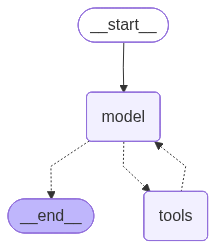

In [8]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from utils import format_messages

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.state import DeepAgentState

# Mock search result
search_result = """모델 컨텍스트 프로토콜(MCP)은 Anthropic이 개발한 개방형 표준 프로토콜로, 
AI 모델과 도구, 데이터베이스, 기타 서비스와 같은 외부 시스템 간의 원활한 통합을 가능하게 합니다. 
이는 표준화된 통신 계층 역할을 하여, 
AI 모델이 다양한 출처의 데이터에 일관되고 효율적인 방식으로 접근하고 활용할 수 있도록 합니다. 본질적으로 MCP는 데이터 교환을 위한 통합된 언어를 제공함으로써 
AI 어시스턴트를 외부 서비스에 연결하는 과정을 간소화합니다.  """


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Create agent using create_react_agent directly
model = init_chat_model(model="anthropic:claude-sonnet-4-6", temperature=0.0)
tools = [ls, read_file, write_file, web_search]

# Create agent with system prompt
agent = create_agent(
    model, tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Start the graph with no `files` in state and an user research request. 

In [9]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Model Context Protocol (MCP)에 대한 개요를 설명해줘.",
            }
        ],
        "files": {},
    }
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Model Context Protocol (MCP)에 대한 개요를 설명해줘.                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 먼저 기존 파일을 확인하고, 웹 검색을 통해 최신 정보를 수집하겠습니다.                                           │
│                                                                                                                 │
│ 🔧 Tool Call: ls                                                                                                │
│    Args: {}                                                                                                     │
│    ID: toolu_017fYycnMwvH3ZQjroNL1iQ3                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP 개요 설명"                                                               │
│ }                                                                                                               │
│    ID: toolu_01EXKQZjBpNPseKFZVm7bWzw                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 모델 컨텍스트 프로토콜(MCP)은 Anthropic이 개발한 개방형 표준 프로토콜로,                                        │
│ AI 모델과 도구, 데이터베이스, 기타 서비스와 같은 외부 시스템 간의 원활한 통합을 가능하게 합니다.                │
│ 이는 표준화된 통신 계층 역할을 하여,                                                                            │
│ AI 모델이 다양한 출처의 데이터에 일관되고 효율적인 방식으로 접근하고 활용할 수 있도록 합니다. 본질적으로 MCP는  │
│ 데이터 교환을 위한 통합된 언어를 제공함으로써                                                                   │
│ AI 어시스턴트를 외부 서비스에 연결하는 과정을 간소화합니다.                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 수집한 정보를 파일로 저장하겠습니다.                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "mcp_overview.md",                                                                               │
│   "content": "# Model Context Protocol (MCP) 개요\n\n## 정의\n- Anthropic이 개발한 개방형 표준 프로토콜\n- AI   │
│ 모델과 외부 시스템(도구, 데이터베이스, 서비스 등) 간의 원활한 통합을 가능하게 함\n- 표준화된 통신 계층 역할     │
│ 수행\n- AI 어시스턴트를 외부 서비스에 연결하는 과정을 간소화\n\n## 핵심 목적\n- AI 모델이 다양한 출처의         │
│ 데이터에 일관되고 효율적인 방식으로 접근 및 활용\n- 데이터 교환을 위한 통합된 언어 제공\n"                      │
│ }                                                                                                               │
│    ID: toolu_016HxUasV6YLbWDYQUo5wSPf                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file mcp_overview.md                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 수집된 정보를 바탕으로 MCP에 대해 상세히 설명드리겠습니다.                                                      │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # 🤖 Model Context Protocol (MCP) 개요                                                                          │
│                                                                                                                 │
│ ## 📌 1. MCP란 무엇인가?                                                                                        │
│                                                                                                                 │
│ **Model Context Protocol(MCP)** 은 **Anthropic**이 2024년에 발표한 **개방형 표준 프로토콜**입니다.              │
│ AI 모델(LLM)과 외부 시스템(도구, 데이터베이스, API, 서비스 등) 사이의 **표준화된 통신 방식**을 정의합니다.      │
│ 쉽게 말해, AI와 외부 세계를 연결하는 **"공통 언어(Universal Connector)"** 역할을 합니다.                        │
│                                                                                                                 │
│ > 💡 비유하자면, MCP는 AI 세계의 **USB-C 포트**와 같습니다. 어떤 기기든 하나의 표준 규격으로 연결할 수 있듯이,  │
│ MCP는 어떤 AI 모델이든 다양한 외부 시스템에 일관된 방식으로 연결할 수 있게 해줍니다.                            │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 🎯 2. 등장 배경 및 필요성                                                                                    │
│                                                                                                                 │
│ 기존에는 AI 모델을 외부 도구나 데이터 소스에 연결하려면:                                                        │
│ - 각 서비스마다 **별도의 커스텀 통합(Custom Integration)** 코드를 작성해야 했고                                 │
│ - 연결 방식이 **파편화**되어 유지보수가 어려웠으며                                                              │
│ - AI가 **최신 정보나 외부 데이터**에 접근하는 데 한계가 있었습니다.                                             │
│                                                                                                                 │
│ MCP는 이러한 문제를 해결하기 위해 **하나의 표준 프로토콜**로 모든 연결을 통합합니다.                            │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 🏗️ 3. 핵심 구조 (Architecture)                                                                               │
│                                                                                                                 │
│ MCP는 **클라이언트-서버 구조**를 기반으로 동작합니다.                                                           │
│                                                                                                                 │
│ | 구성 요소 | 역할 |                                                                                            │
│ |---|---|                                                                                                       │
│ | **MCP Host** | AI 모델이 실행되는 환경 (예: Claude Desktop, IDE 등) |                                         │
│ | **MCP Client** | Host 내에서 MCP 서버와 통신하는 클라이언트 |                                                 │
│ | **MCP Server** | 외부 데이터/도구를 AI에게 제공하는 경량 서버 |                                 

We can see the file saved in our mock file system. 

In [10]:
result["files"]

{'mcp_overview.md': '# Model Context Protocol (MCP) 개요\n\n## 정의\n- Anthropic이 개발한 개방형 표준 프로토콜\n- AI 모델과 외부 시스템(도구, 데이터베이스, 서비스 등) 간의 원활한 통합을 가능하게 함\n- 표준화된 통신 계층 역할 수행\n- AI 어시스턴트를 외부 서비스에 연결하는 과정을 간소화\n\n## 핵심 목적\n- AI 모델이 다양한 출처의 데이터에 일관되고 효율적인 방식으로 접근 및 활용\n- 데이터 교환을 위한 통합된 언어 제공\n'}

Trace: 
https://smith.langchain.com/public/b03e20b4-e908-488d-84a9-8f891d17addd/r
<!-- https://smith.langchain.com/public/1066102f-d7b3-423c-b556-006865a1d479/r -->